📊 01_arxiv_industry_analysis.ipynb
 Analysis Target: Explore LLM paper trends across different industries from 2015–2025

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Markdown, display

1️⃣ Path Setup

In [ ]:
DATA_PATH = Path("../data/raw/arxiv_stats_by_industry.csv")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"📂 Loading data file: {DATA_PATH}")

📂 Loading data file: ..\data\raw\arxiv_stats_by_industry.csv


2️⃣ Load and Initial Inspection

In [4]:
df = pd.read_csv(DATA_PATH)
display(df.head())

print(f"Total {len(df)} records, columns: {list(df.columns)}")

# Expected columns example:
# year, industry, paper_count
required_cols = {"year", "industry", "publication_count"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"Missing required columns: {required_cols - set(df.columns)}")

df["year"] = df["year"].astype(int)

,year,industry,publication_count,query,timestamp
0,2020,education,29209,"((large language model OR LLM OR ""LL models"" O...",2025-10-07T02:22:57.403233
1,2020,medicine,4402,"((large language model OR LLM OR ""LL models"" O...",2025-10-07T02:22:59.152636
2,2020,finance,2503,"((large language model OR LLM OR ""LL models"" O...",2025-10-07T02:23:00.909853
3,2020,science,56190,"((large language model OR LLM OR ""LL models"" O...",2025-10-07T02:23:02.744649
4,2020,entertainment,4187,"((large language model OR LLM OR ""LL models"" O...",2025-10-07T02:23:04.492494


Total 30 records, columns: ['year', 'industry', 'publication_count', 'query', 'timestamp']


3️⃣ Summary Statistics

In [6]:
summary = df.groupby("industry")["publication_count"].sum().sort_values(ascending=False)
display(summary)

industry
science          424233
education        252309
medicine          36992
entertainment     29747
finance           19913
Name: publication_count, dtype: int64

4️⃣ Trend Line Chart

Saved: results/arxiv_industry_trends.png


C:\Users\ahao\AppData\Local\Temp\ipykernel_18008\50610988.py:14: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ahao\AppData\Local\Temp\ipykernel_18008\50610988.py:15: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig(RESULTS_DIR / "arxiv_industry_trends.png", dpi=300)
c:\Users\ahao\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


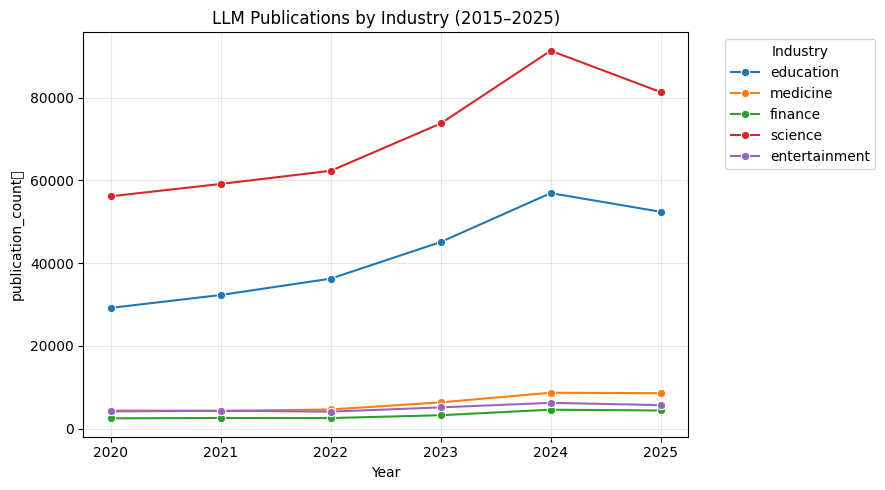

In [ ]:
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=df,
    x="year",
    y="publication_count",
    hue="industry",
    marker="o"
)
plt.title("LLM Publications by Industry (2015–2025)")
plt.xlabel("Year")
plt.ylabel("publication_count	")
plt.legend(title="Industry", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "arxiv_industry_trends.png", dpi=300)
print("Saved: results/01_arxiv_industry_trends.png")
plt.show()

5️⃣ Share Analysis (Industry paper share over time)

Saved: results/arxiv_industry_share.png


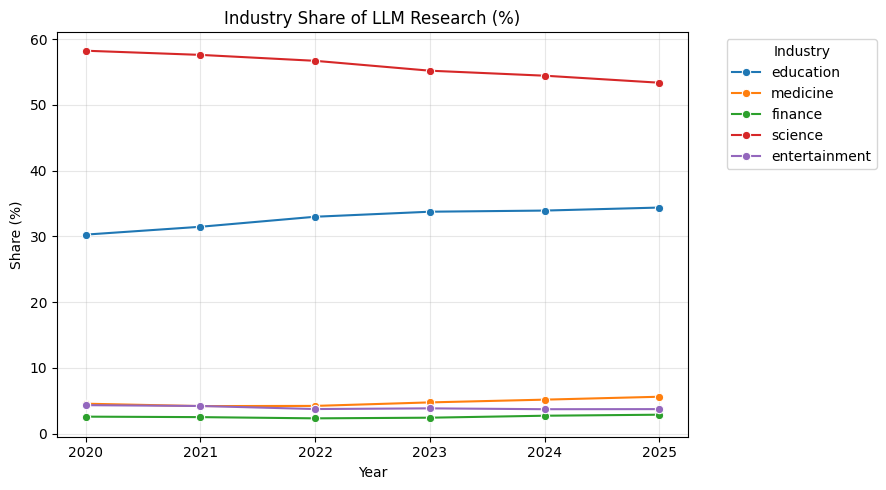

In [ ]:
total_by_year = df.groupby("year")["publication_count"].sum().rename("total")
df = df.merge(total_by_year, on="year")
df["share"] = df["publication_count"] / df["total"] * 100

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=df,
    x="year",
    y="share",
    hue="industry",
    marker="o"
)
plt.title("Industry Share of LLM Research (%)")
plt.xlabel("Year")
plt.ylabel("Share (%)")
plt.legend(title="Industry", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "arxiv_industry_share.png", dpi=300)
print("Saved: results/01_arxiv_industry_share.png")
plt.show()

6️⃣ Brief Analysis Output

In [10]:
peak_year = df.loc[df["publication_count"].idxmax(), "year"]
top_industry = summary.index[0]
growth = (
    df.groupby("year")["publication_count"].sum().iloc[-1] /
    df.groupby("year")["publication_count"].sum().iloc[0]
)

summary_md = f"""
## 🧩 Analysis Summary (Arxiv Industry Trends)

- Time Period: {df['year'].min()} – {df['year'].max()}
- Industries Covered: {df['industry'].nunique()} (e.g., {', '.join(df['industry'].unique()[:5])} ...)
- Total paper count grew by approx. **{growth:.1f}x**
- Top industry for LLM research: **{top_industry}**
- Peak publication year: **{peak_year}**
- Outputs:
  - `results/arxiv_industry_trends.png`: Annual trend chart
  - `results/arxiv_industry_share.png`: Industry share change chart
"""

display(Markdown(summary_md))


## 🧩 Analysis Summary (Arxiv Industry Trends)

- Time Period: 2020 – 2025
- Industries Covered: 5 (e.g., education, medicine, finance, science, entertainment ...)
- Total paper count grew by approx. **1.6x**
- Top industry for LLM research: **science**
- Peak publication year: **2024**
- Outputs:
  - `results/arxiv_industry_trends.png`: Annual trend chart
  - `results/arxiv_industry_share.png`: Industry share change chart
